In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('diabetic_encoded.csv')

In [4]:
df = df.dropna()

Все данные были закодированы, таким образом что все признаки были числовыми. Теперь можем приступать к обучению модели. В качестве таргета - был ли госпитализирован пациент в течении 30 дней после выписки.

In [5]:
y = (df["readmitted"] == 2).astype(int)

In [6]:
X = df.drop(columns=["readmitted", "patient_nbr"]).astype(float)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test_cal, y_train, y_test_cal = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=67
)

X_test, X_cal, y_test, y_cal = train_test_split(
    X_test_cal,
    y_test_cal,
    test_size=0.5,
    stratify=y_test_cal,
    random_state=67
)

Итого у нас получается:

* 70% train
* 15% calibration
* 15% test

In [8]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb = HistGradientBoostingClassifier(
    random_state=67,
    early_stopping=True,
    validation_fraction=0.1
)

In [9]:
from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate_proba(y_true, proba):
    print("ROC AUC:", roc_auc_score(y_true, proba))
    print("PR AUC:", average_precision_score(y_true, proba))
    print("Real positive rate:", y_true.mean())

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluate_classification(y_true, proba, threshold=0.5):
    y_pred = (proba >= threshold).astype(int)
    
    print(f"Threshold = {threshold}")
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall:", recall_score(y_true, y_pred, zero_division=0))
    print("F1:", f1_score(y_true, y_pred, zero_division=0))
    print()
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))
    print()
    print("Classification report:")
    print(classification_report(y_true, y_pred, zero_division=0))

In [11]:
gb_params = {
    "learning_rate": [0.01, 0.05, 0.1],
    "max_iter": [150, 175, 200],
    "max_leaf_nodes": [12, 15, 18],
    "min_samples_leaf": [5, 10, 15],
    "l2_regularization": [0.15, 0.2, 0.25]
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

gb_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=gb_params,
    n_iter=20,
    scoring="average_precision",
    cv=5,
    random_state=67,
    verbose=1
)

gb_search.fit(X_train, y_train)

print("Наилучшие параметры:", gb_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Наилучшие параметры {'min_samples_leaf': 15, 'max_leaf_nodes': 18, 'max_iter': 200, 'learning_rate': 0.05, 'l2_regularization': 0.2}


In [13]:
best_gb = gb_search.best_estimator_

gb_proba_test = best_gb.predict_proba(X_test)[:, 1]

evaluate_proba(y_test, gb_proba_test)
print()
evaluate_classification(y_test, gb_proba_test, threshold=0.11)

ROC AUC: 0.6887639301729775
PR AUC: 0.24363315977468064
Real positive rate: 0.11156970649895179

Threshold = 0.11
Precision: 0.18479206542543936
Recall: 0.6236054022313564
F1: 0.2851006711409396

Confusion matrix:
[[8876 4685]
 [ 641 1062]]

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.65      0.77     13561
           1       0.18      0.62      0.29      1703

    accuracy                           0.65     15264
   macro avg       0.56      0.64      0.53     15264
weighted avg       0.85      0.65      0.72     15264



In [14]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

gb_calibrated = CalibratedClassifierCV(
    FrozenEstimator(best_gb),
    method="sigmoid"
)

gb_calibrated.fit(X_cal, y_cal)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",FrozenEstimat...dom_state=67))
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. In

In [15]:
gb_proba_test_calibrated = gb_calibrated.predict_proba(X_test)[:, 1]

evaluate_proba(y_test, gb_proba_test_calibrated)
print()
evaluate_classification(y_test, gb_proba_test_calibrated, threshold=0.11)

ROC AUC: 0.6887639301729775
PR AUC: 0.24363315977468064
Real positive rate: 0.11156970649895179

Threshold = 0.11
Precision: 0.1887339250135845
Recall: 0.6118614210217264
F1: 0.2884828349944629

Confusion matrix:
[[9082 4479]
 [ 661 1042]]

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.67      0.78     13561
           1       0.19      0.61      0.29      1703

    accuracy                           0.66     15264
   macro avg       0.56      0.64      0.53     15264
weighted avg       0.85      0.66      0.72     15264



In [16]:
threshold_30 = np.quantile(gb_proba_test_calibrated, 0.7)

evaluate_classification(
    y_test,
    gb_proba_test_calibrated,
    threshold=threshold_30
)

print("Порог отсекающий топ-30%:", threshold_30)

Threshold = 0.11998949249211309
Precision: 0.20222756060275168
Recall: 0.543746330005872
F1: 0.2948105698822031

Confusion matrix:
[[9908 3653]
 [ 777  926]]

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.73      0.82     13561
           1       0.20      0.54      0.29      1703

    accuracy                           0.71     15264
   macro avg       0.56      0.64      0.56     15264
weighted avg       0.85      0.71      0.76     15264

Порог отсекающий топ-30%: 0.11998949249211309


(array([2.280e+02, 2.000e+00, 0.000e+00, 7.500e+01, 2.010e+02, 4.910e+02,
        8.640e+02, 1.021e+03, 1.230e+03, 1.227e+03, 1.199e+03, 9.620e+02,
        8.970e+02, 8.730e+02, 7.230e+02, 7.020e+02, 5.750e+02, 4.890e+02,
        3.250e+02, 2.560e+02, 2.410e+02, 1.970e+02, 2.140e+02, 2.360e+02,
        2.170e+02, 2.080e+02, 1.840e+02, 1.620e+02, 1.200e+02, 9.800e+01,
        9.300e+01, 7.200e+01, 7.200e+01, 5.100e+01, 6.900e+01, 6.500e+01,
        4.500e+01, 4.600e+01, 4.000e+01, 3.600e+01, 2.900e+01, 1.700e+01,
        2.900e+01, 3.200e+01, 2.400e+01, 2.400e+01, 2.300e+01, 2.400e+01,
        1.800e+01, 1.600e+01, 1.200e+01, 1.800e+01, 1.400e+01, 1.100e+01,
        1.000e+01, 1.000e+01, 1.100e+01, 7.000e+00, 1.200e+01, 8.000e+00,
        9.000e+00, 8.000e+00, 8.000e+00, 5.000e+00, 4.000e+00, 7.000e+00,
        3.000e+00, 5.000e+00, 3.000e+00, 3.000e+00, 1.000e+00, 8.000e+00,
        7.000e+00, 5.000e+00, 4.000e+00, 5.000e+00, 3.000e+00, 0.000e+00,
        1.000e+00, 2.000e+00, 0.000e+0

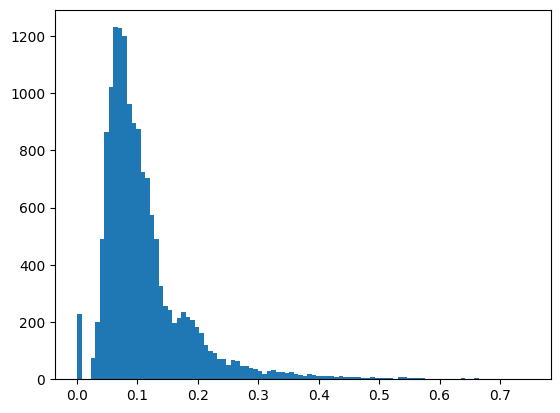

In [17]:
plt.hist(gb_proba_test_calibrated, bins=100)

In [68]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    best_gb,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=5,
    random_state=67
)

In [69]:
gb_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
})

gb_importance = gb_importance.sort_values(
    "importance_mean",
    ascending=False
)

gb_importance.head(20)

,feature,importance_mean,importance_std
8,number_inpatient,0.081708,0.002151
95,discharge_disposition_id_22,0.029436,0.000613
77,discharge_disposition_id_3,0.010036,0.000645
76,discharge_disposition_id_2,0.009985,0.000602
51,payer_code_Missing,0.005337,0.001577
9,number_diagnoses,0.004982,0.001259
85,discharge_disposition_id_11,0.004855,0.000778
7,number_emergency,0.004747,0.000740
79,discharge_disposition_id_5,0.004631,0.000833
1,age,0.003142,0.001245
